In [46]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
matrix_mse = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_figureResults/multiregion_samecenters_seed10_trainosd50_V3/mse_losses.csv')
matrix_mse

,HC_HC,HC_PFC,PFC_PFC,PFC_HC
0,1.885055,1.846202,1.840139,1.885002
1,1.847097,1.880209,1.890849,1.845873
2,1.748669,1.810338,1.804573,1.742398
3,1.683363,1.790425,1.764935,1.696134
4,1.651557,1.646186,1.615357,1.664154
...,...,...,...,...
9995,0.917185,0.970990,0.895997,0.972316
9996,0.871870,0.936926,0.869392,0.952042
9997,0.916236,0.908244,0.860291,0.968423
9998,0.965530,0.965430,0.878167,1.018910


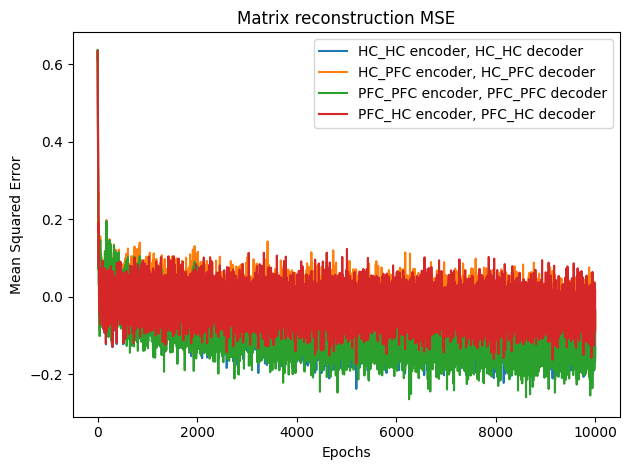

In [48]:
for i, set in enumerate(['HC_HC', 'HC_PFC', 'PFC_PFC', 'PFC_HC']):
    plt.plot(np.log(matrix_mse[f'{set}']), label=f'{set} encoder, {set} decoder')

plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Matrix reconstruction MSE')
plt.legend()
plt.tight_layout()

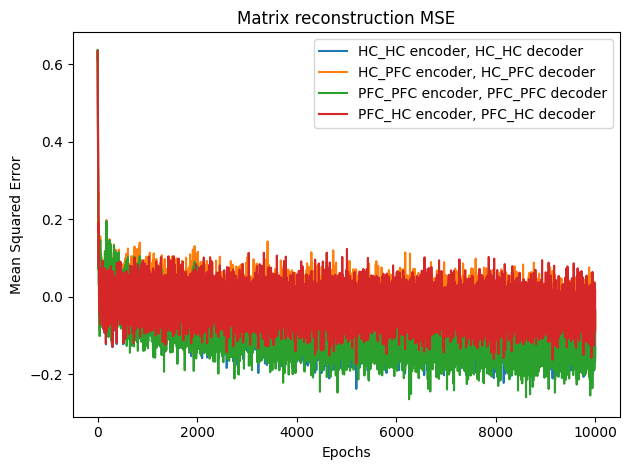

In [49]:
for i, set in enumerate(['HC_HC', 'HC_PFC', 'PFC_PFC', 'PFC_HC']):
    plt.plot(np.log(matrix_mse[f'{set}']), label=f'{set} encoder, {set} decoder')

plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Matrix reconstruction MSE')
plt.legend()
plt.tight_layout()

In [50]:
matrix_mse_last2500 = matrix_mse.iloc[-2500:, :]

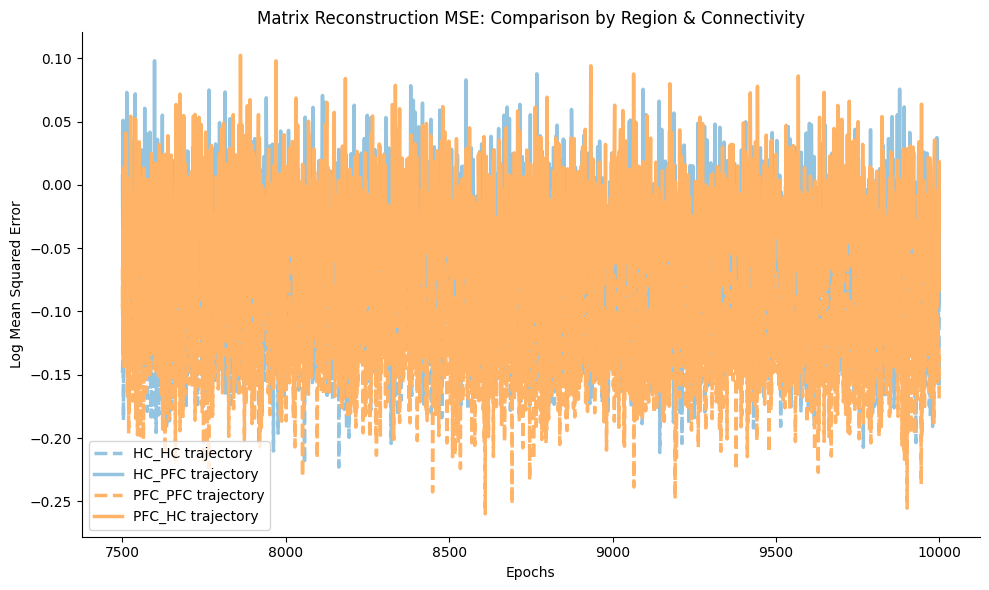

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Use the hex codes we converted earlier for consistency
color_blue = '#94C4DF'   # From cmap2(0.4)
color_orange = '#FFB367' # From cmap1(0.85)

datasets = ['HC_HC', 'HC_PFC', 'PFC_PFC', 'PFC_HC']

plt.figure(figsize=(10, 6))

for dataset_name in datasets:
    # Split the string by the underscore (e.g., 'HC_PFC' -> ['HC', 'PFC'])
    parts = dataset_name.split('_')
    start_loc = parts[0]
    end_loc = parts[1]
    
    # 1. Determine Color based on the beginning (start_loc)
    plot_color = color_blue if start_loc == 'HC' else color_orange
    
    # 2. Determine Line Style based on whether they are the same or different
    line_style = '--' if start_loc == end_loc else '-'
    
    # Plotting using the logic-derived styles
    # Assuming matrix_mse is your dictionary of data
    plt.plot(np.log(matrix_mse_last2500[dataset_name]), 
             label=f'{dataset_name} trajectory', 
             color=plot_color, 
             linestyle=line_style, 
             linewidth=2.5)

# Formatting
plt.xlabel('Epochs')
plt.ylabel('Log Mean Squared Error')
plt.title('Matrix Reconstruction MSE: Comparison by Region & Connectivity')

# Remove grid as requested previously
plt.grid(False)

# Clean up spines for a polished look
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.legend()
plt.tight_layout()
plt.show()

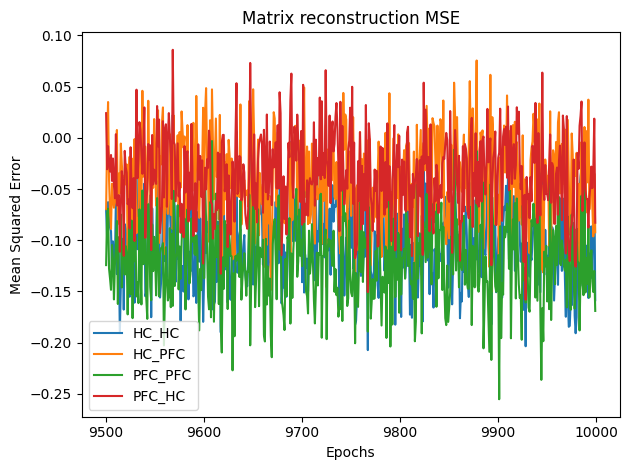

In [52]:
matrix_mse_last500 = matrix_mse.iloc[-500:, :]
for i, set in enumerate(['HC_HC', 'HC_PFC', 'PFC_PFC', 'PFC_HC']):
    plt.plot(np.log(matrix_mse_last500[f'{set}']), label=f'{set}')

plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('Matrix reconstruction MSE')
plt.legend()
plt.tight_layout()

In [53]:
std = np.std(matrix_mse.iloc[-500:, :], axis=0)
mean = np.mean(matrix_mse.iloc[-500:, :], axis=0)

In [54]:
mean

HC_HC      0.902927
HC_PFC     0.961175
PFC_PFC    0.886388
PFC_HC     0.964545
dtype: float64

In [55]:
std

HC_HC      0.034965
HC_PFC     0.041270
PFC_PFC    0.035473
PFC_HC     0.038488
dtype: float64

In [56]:
np.max(matrix_mse.iloc[-500:, :], axis=0), np.min(matrix_mse.iloc[-500:, :], axis=0)

(HC_HC      1.022601
 HC_PFC     1.078462
 PFC_PFC    0.996939
 PFC_HC     1.089781
 dtype: float64,
 HC_HC      0.812821
 HC_PFC     0.828666
 PFC_PFC    0.774727
 PFC_HC     0.853840
 dtype: float64)

In [71]:
import scipy.stats as stats

In [88]:
f_stat, p_value = stats.f_oneway(matrix_mse.iloc[-100:, 0], matrix_mse.iloc[-100:, 1], matrix_mse.iloc[-100:, 2], matrix_mse.iloc[-100:, 3])
f_stat, p_value

(102.87859742758761, 2.9537876845793372e-49)

In [89]:
f_stat, p_value = stats.f_oneway(matrix_cfm.iloc[-100:, 1], matrix_cfm.iloc[-100:, 3])
f_stat, p_value

(0.006291521323575274, 0.936858913546514)

In [ ]:
f_stat, p_value = stats.f_oneway(matrix_cfm.iloc[-100:, 1], matrix_cfm.iloc[-100:, 3])
f_stat, p_value

(array([272., 136.,  46.,  17.,  13.,   9.,   3.,   2.,   0.,   2.]),
 array([0.00027316, 0.00357203, 0.0068709 , 0.01016978, 0.01346865,
        0.01676752, 0.02006639, 0.02336526, 0.02666413, 0.029963  ,
        0.03326187]),
 <BarContainer object of 10 artists>)

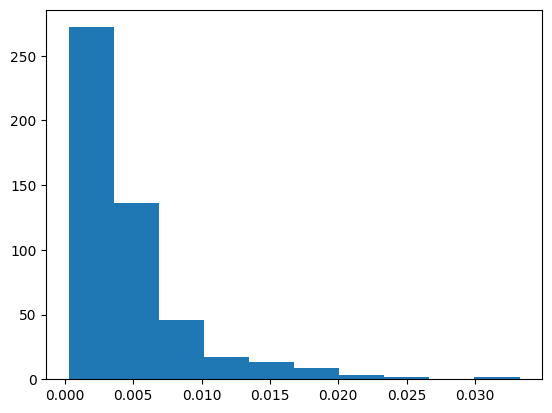

In [86]:
plt.hist(matrix_cfm.iloc[-500:, 0].values)

(array([289., 119.,  44.,  19.,  15.,   6.,   4.,   2.,   0.,   2.]),
 array([0.00024058, 0.00358167, 0.00692277, 0.01026386, 0.01360495,
        0.01694605, 0.02028714, 0.02362824, 0.02696933, 0.03031042,
        0.03365152]),
 <BarContainer object of 10 artists>)

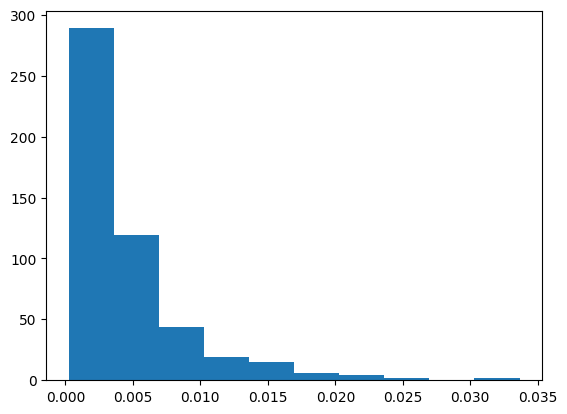

In [82]:
plt.hist(matrix_cfm.iloc[-500:, 3].values)

In [84]:
stat, p_value = stats.kruskal(matrix_cfm.iloc[-500:, 1], matrix_cfm.iloc[-500:, 3])
stat, p_value

(0.0020151848148088902, 0.9641943420870688)

In [57]:
matrix_cfm = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_figureResults/multiregion_samecenters_seed10_trainosd50_V3/mse_cfm_losses.csv')
matrix_cfm

,HC_HC,HC_PFC,PFC_PFC,PFC_HC
0,0.631274,0.727913,0.737862,0.776056
1,0.716805,0.852694,0.793542,0.690497
2,0.676172,0.736008,0.777228,0.655655
3,0.650776,0.649390,0.789914,0.722598
4,0.613685,0.616552,0.901848,0.988016
...,...,...,...,...
9995,0.001065,0.000792,0.000996,0.000938
9996,0.006621,0.006651,0.007103,0.006746
9997,0.006819,0.006995,0.007731,0.006746
9998,0.001926,0.001645,0.001724,0.001685


In [58]:
std_cfm = np.std(matrix_cfm.iloc[-500:, :], axis=0)
mean_cfm = np.mean(matrix_cfm.iloc[-500:, :], axis=0)

In [59]:
mean_cfm

HC_HC      0.004594
HC_PFC     0.004489
PFC_PFC    0.004610
PFC_HC     0.004496
dtype: float64

In [60]:
std_cfm

HC_HC      0.004602
HC_PFC     0.004586
PFC_PFC    0.004690
PFC_HC     0.004625
dtype: float64

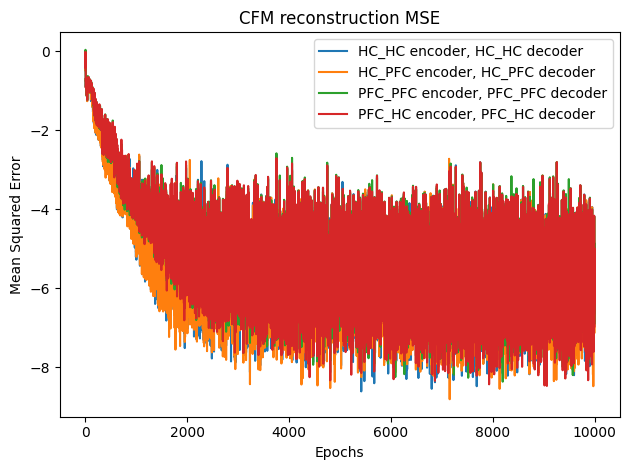

In [61]:
for i, set in enumerate(['HC_HC', 'HC_PFC', 'PFC_PFC', 'PFC_HC']):
    plt.plot(np.log(matrix_cfm[f'{set}']), label=f'{set} encoder, {set} decoder')

plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('CFM reconstruction MSE')
plt.legend()
plt.tight_layout()

In [62]:
cfm_mse_last500 = matrix_cfm.iloc[-500:, :]

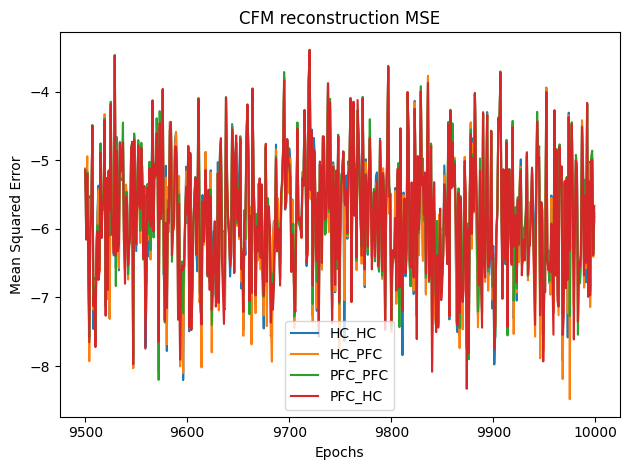

In [63]:
for i, set in enumerate(['HC_HC', 'HC_PFC', 'PFC_PFC', 'PFC_HC']):
    plt.plot(np.log(cfm_mse_last500[f'{set}']), label=f'{set}')

plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('CFM reconstruction MSE')
plt.legend()
plt.tight_layout()

With reran model

In [64]:
output_folder = '/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_figureResults/multiregion_samecenters_seed10_trainosd50_V2'

In [65]:
total_loss = pd.read_csv(os.path.join(output_folder, 'total_loss.csv'))

Text(0, 0.5, 'Total training Loss')

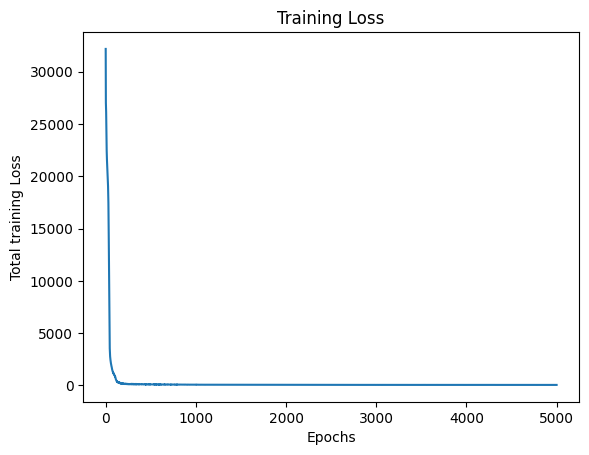

In [66]:
plt.figure()
plt.plot(total_loss, label='Training loss')                                                                          
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Total training Loss')            
#plt.savefig(os.path.join(output_folder, 'train_loss.png'))

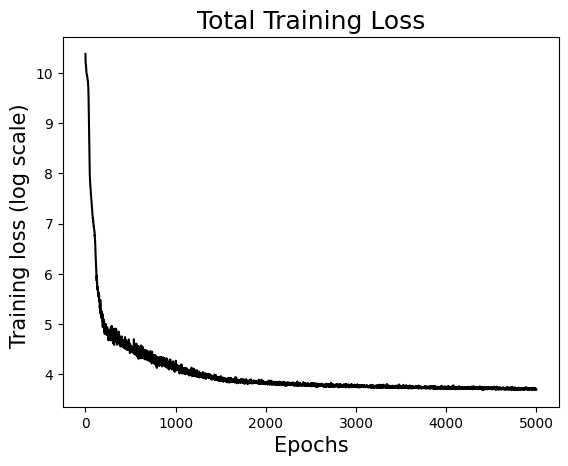

In [67]:
plt.figure()
plt.plot(np.log(total_loss), label='Training loss', color='black')                                                                          
plt.title('Total Training Loss', fontsize=18)
plt.xlabel('Epochs', fontsize=15)
plt.ylabel('Training loss (log scale) ', fontsize=15)    
plt.savefig(os.path.join(output_folder, 'log_train_loss.png'), dpi=600)

In [68]:
osd_over_epochs = pd.read_csv('/home/rachel/Desktop/mm-vae results/multiregion_adbxd_cr_figureResults/multiregion_samecenters_seed10_trainosd50_V2/osd_over_epochs.csv')
osd_over_epochs 

,0
0,0.920597
1,0.974466
2,0.988588
3,0.991122
4,0.995503
...,...
4995,0.999997
4996,0.999988
4997,0.999986
4998,0.999993


In [69]:
osd = osd_over_epochs['0']

In [70]:
np.mean(osd[-500:]), np.std(osd[-500:])

(0.9999748939399999, 2.703739772012895e-05)